In [12]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
 
url =  "https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/imdb.csv" 
df = pd.read_csv(url)

print(df.head)
df.shape

<bound method NDFrame.head of      Unnamed: 0  Rank                    Title                     Genre  \
0             0     1  Guardians of the Galaxy   Action,Adventure,Sci-Fi   
1             1     2               Prometheus  Adventure,Mystery,Sci-Fi   
2             2     3                    Split           Horror,Thriller   
3             3     4                     Sing   Animation,Comedy,Family   
4             4     5            Suicide Squad  Action,Adventure,Fantasy   
..          ...   ...                      ...                       ...   
995         995   996     Secret in Their Eyes       Crime,Drama,Mystery   
996         996   997          Hostel: Part II                    Horror   
997         997   998   Step Up 2: The Streets       Drama,Music,Romance   
998         998   999             Search Party          Adventure,Comedy   
999         999  1000               Nine Lives     Comedy,Family,Fantasy   

                                           Description   

(1000, 33)

In [13]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df["Rating"],
    groups=df["Year"],
    alpha=0.05,
)
tukey.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
2006,2007,0.009,1.0,-0.598,0.6159,False
2006,2008,-0.3404,0.7793,-0.95,0.2692,False
2006,2009,-0.1642,0.9987,-0.7765,0.4481,False
2006,2010,-0.2983,0.8695,-0.889,0.2923,False
2006,2011,-0.2869,0.8894,-0.8716,0.2978,False
2006,2012,-0.2,0.9905,-0.7828,0.3828,False
2006,2013,-0.3129,0.7512,-0.8594,0.2335,False
2006,2014,-0.2872,0.8273,-0.8273,0.2528,False
2006,2015,-0.5226,0.0481,-1.0432,-0.002,True
2006,2016,-0.6883,0.0002,-1.169,-0.2076,True


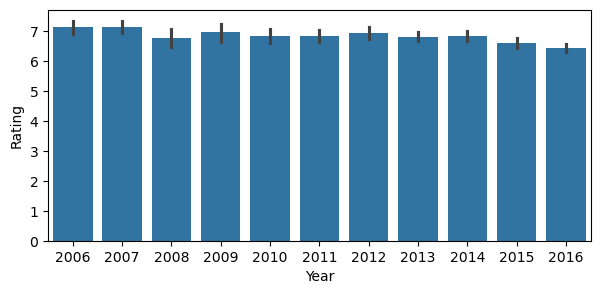

In [14]:
plt.figure(figsize=(7,3))
bar = sns.barplot(data=df, x="Year", y= "Rating")


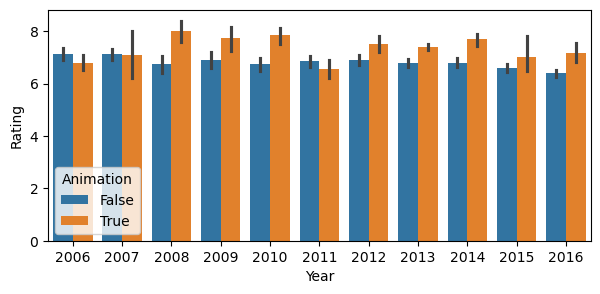

In [15]:
plt.figure(figsize=(7,3))
bar = sns.barplot(data=df, x="Year", y="Rating", hue="Animation")

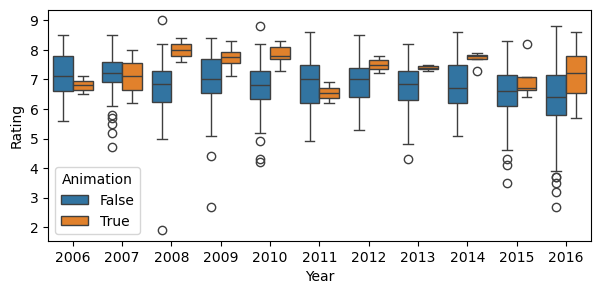

In [17]:
plt.figure(figsize=(7,3))
box = sns.boxplot(data=df, x="Year", y= "Rating", hue="Animation")

In [ ]:
groups = [
    ["Action", "Adventure", "Sci-Fi"],
    ["Drama"],
    ["Comedy", "Romance"],
    ["Animation", "Adventure", "Comedy"]
]
df["Genre"] = df["Genre"].str.split(",")

alpha = 0.05  # significance level

samples = [df.loc[df["Genre"].apply(lambda x: bool(set(x) & set(g))), "Rating"] for g in groups]
f, p = stats.f_oneway(*samples)
dfb = len(samples) - 1
dfw = sum([len(s) for s in samples]) - len(samples)
cf = stats.f.ppf(1-alpha, dfb, dfw)
print(f"f:{f:.4f} crit_f: {cf:.4f}, p: {p:.4f}")

TypeError: 'float' object is not iterable